# Exploratory Data Analysis – Climate patterns 2022

## Business Context

The dataset has been successfully collected and validated. The next step is to understand what the data reveals.

Exploratory Data Analysis (EDA) helps identify the main characteristics of the dataset, detect potential inconsistencies, and uncover patterns that may influence temperature forecasting.

Rather than drawing conclusions too early, this phase builds a solid understanding of the data and provides the context needed for the analyses that follow.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

## Loading the Raw Dataset

The validated weather dataset is loaded to begin the exploratory analysis.

Using the same dataset produced during the ingestion phase ensures consistency throughout the project and provides a reliable starting point for understanding the observations collected across all selected cities.

In [2]:
weather_df = pd.read_csv("../data/raw/weather_2022_raw.csv")
weather_df.head()

weather_df["time"] = pd.to_datetime(weather_df["time"])

## Understanding the Dataset

Before exploring weather patterns, it is important to verify the overall structure of the dataset.

This initial review confirms the available variables, their data types, and the presence of any missing values. Establishing this baseline helps ensure that subsequent analyses are based on complete and consistent information.

In [3]:
weather_df.info()

missing_values = weather_df.isna().sum()
missing_percent = (weather_df.isna().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing_values,
    'missing_percent': missing_percent
})

missing_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   time                7300 non-null   datetime64[ns]
 1   temperature_2m_max  7300 non-null   float64       
 2   temperature_2m_min  7300 non-null   float64       
 3   precipitation_sum   7300 non-null   float64       
 4   city                7300 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 285.3+ KB


,missing_count,missing_percent
time,0,0.0
temperature_2m_max,0,0.0
temperature_2m_min,0,0.0
precipitation_sum,0,0.0
city,0,0.0


### Interpretation

The dataset contains **7,300 weather observations** across five variables: date, maximum temperature, minimum temperature, precipitation, and city.

No missing values were detected, and all variables use the expected data types, indicating that the dataset is complete and internally consistent.

At this stage, no additional data cleaning is required, allowing the analysis to focus on understanding the data rather than addressing quality issues.

## Univariate Analysis

This first step is to examine each variable individually.

Understanding how temperatures and precipitation are distributed provides an initial overview of the dataset, helping identify common conditions, the range of observed values, and potential extreme observations.

This baseline understanding will support the interpretation of broader weather patterns in the following analyses.

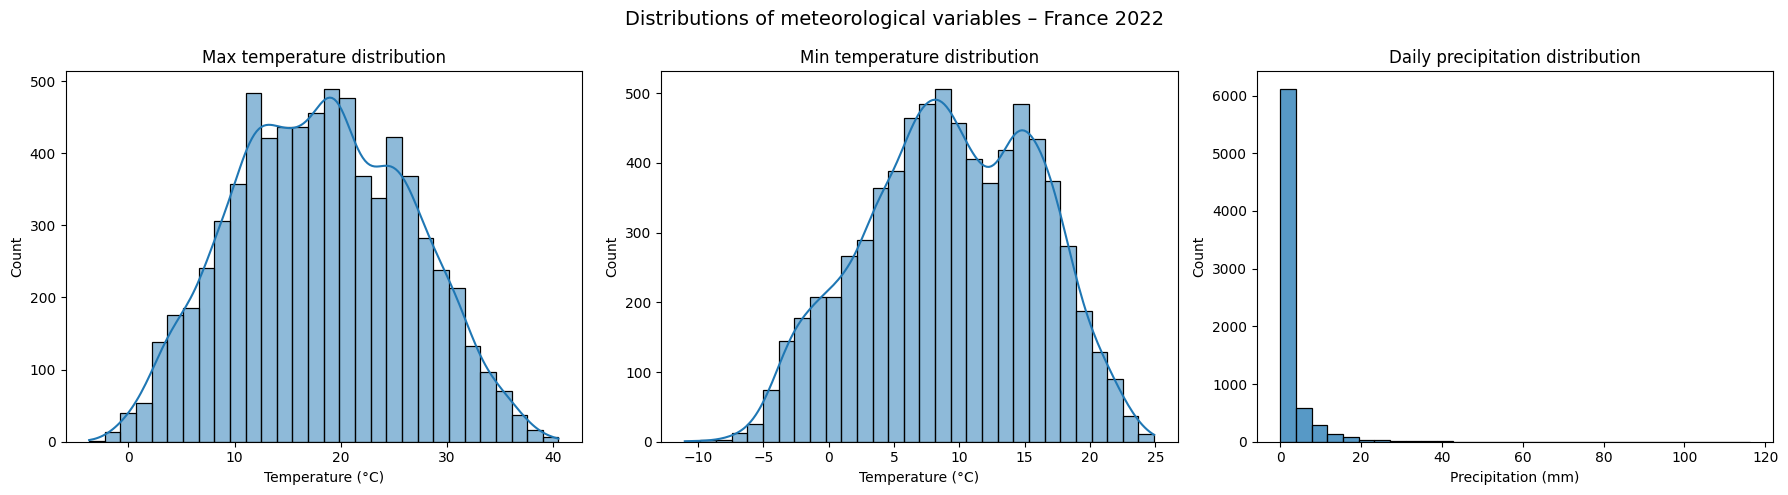

In [4]:
# Create output directory for figures
os.makedirs("../outputs/figures", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(weather_df['temperature_2m_max'], kde=True, bins=30, ax=axes[0])
axes[0].set_title("Max temperature distribution")
axes[0].set_xlabel("Temperature (°C)")

sns.histplot(weather_df['temperature_2m_min'], kde=True, bins=30, ax=axes[1])
axes[1].set_title("Min temperature distribution")
axes[1].set_xlabel("Temperature (°C)")

sns.histplot(weather_df['precipitation_sum'], kde=False, bins=30, ax=axes[2])
axes[2].set_title("Daily precipitation distribution")
axes[2].set_xlabel("Precipitation (mm)")

plt.suptitle("Distributions of meteorological variables – France 2022", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/distributions_overview.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

### Interpretation

The temperature distributions are relatively smooth and spread across a broad range of values, reflecting the seasonal variability observed across the selected cities.

In contrast, daily precipitation is highly concentrated around low values, with many days recording little or no rainfall and a smaller number of days associated with heavier precipitation.

Overall, these distributions are consistent with typical annual weather conditions and provide an initial understanding of the variables before exploring their evolution over time.

## Temporal analysis – Global evolution (ALL CITIES)

Weather conditions are not static. Beyond their overall distributions, it is important to examine how temperature and precipitation evolve throughout the year.

Observing these temporal trends provides a broader view of seasonal behavior across the selected cities and helps identify recurring patterns that may not be visible when each variable is analyzed independently.

This perspective complements the previous analysis by showing how weather conditions change over time.

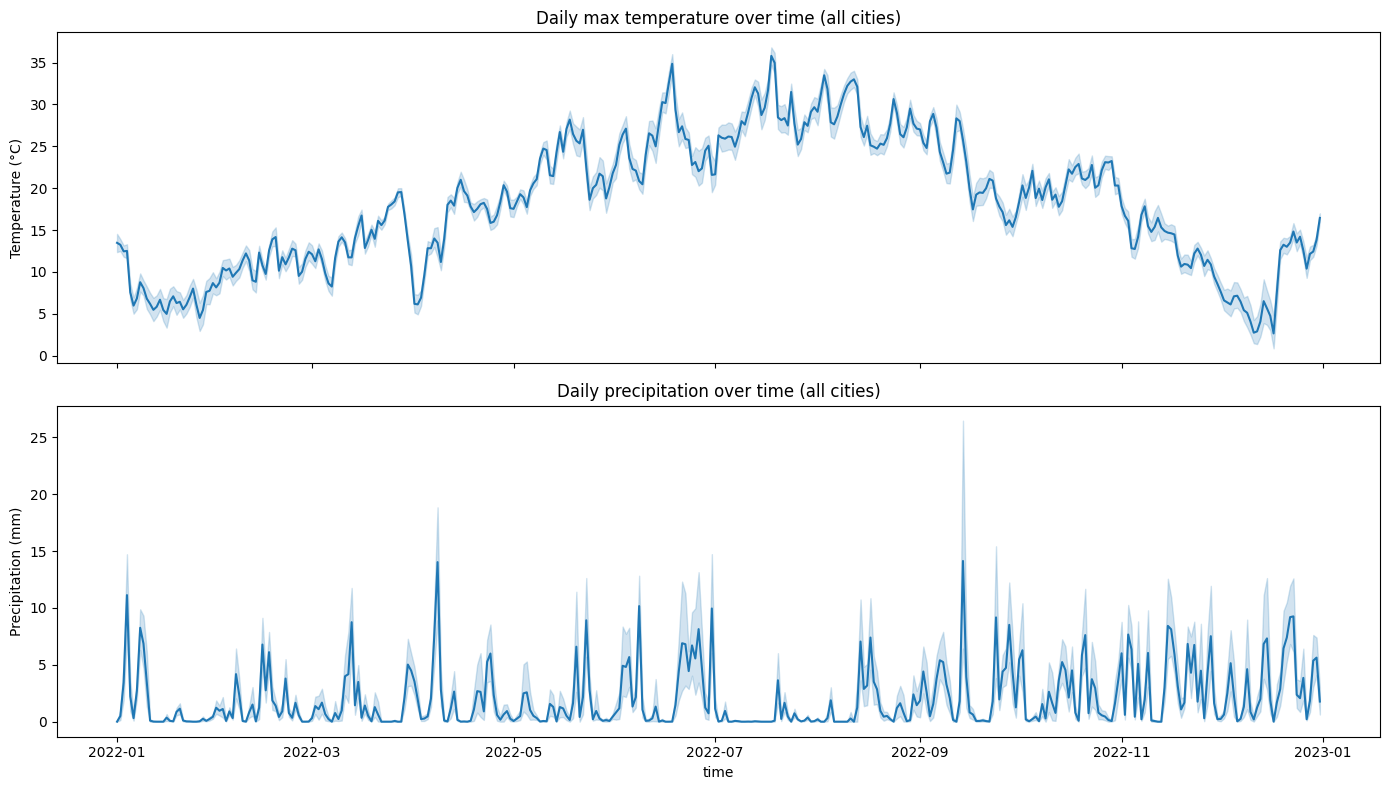

In [5]:
weather_df_sorted = weather_df.sort_values("time")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

sns.lineplot(data=weather_df_sorted, x="time", y="temperature_2m_max", ax=axes[0])
axes[0].set_title("Daily max temperature over time (all cities)")
axes[0].set_ylabel("Temperature (°C)")

sns.lineplot(data=weather_df_sorted, x="time", y="precipitation_sum", ax=axes[1])
axes[1].set_title("Daily precipitation over time (all cities)")
axes[1].set_ylabel("Precipitation (mm)")

plt.tight_layout()
plt.savefig("../outputs/figures/global_time_series.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()



### Interpretation

The temperature series follows a clear annual cycle, with progressively higher values during the middle of the year and lower values at the beginning and end of the observation period.

Precipitation exhibits a more irregular pattern, with rainfall events occurring throughout the year and varying considerably from one day to another.

These observations highlight the different temporal behaviors of the two variables and suggest that seasonality is an important characteristic of the dataset.

## Monthly seasonality – Global

## Monthly Seasonality

After examining the overall evolution of weather conditions throughout the year, the next step is to summarize these observations on a monthly basis.

Aggregating the data by month makes seasonal patterns easier to identify and provides a clearer view of how temperatures and precipitation vary over the course of the year.

This simplified perspective helps highlight recurring climate trends across the selected cities.

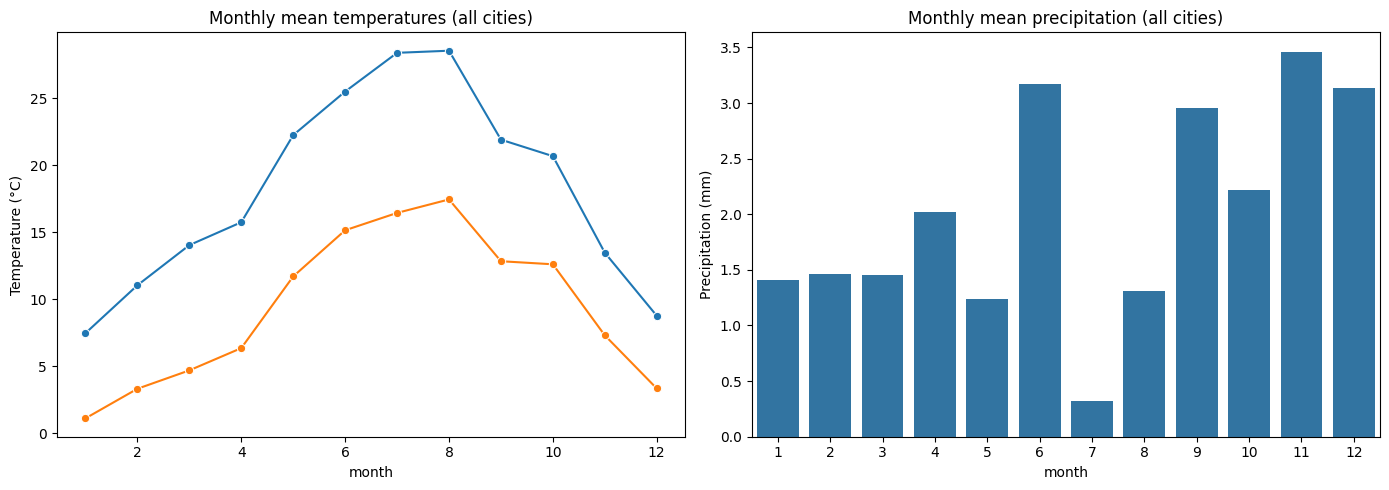

In [6]:
weather_df["month"] = weather_df["time"].dt.month

monthly_mean = weather_df.groupby("month")[[
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum"
]].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=monthly_mean, x="month", y="temperature_2m_max", marker="o", ax=axes[0])
sns.lineplot(data=monthly_mean, x="month", y="temperature_2m_min", marker="o", ax=axes[0])
axes[0].set_title("Monthly mean temperatures (all cities)")
axes[0].set_ylabel("Temperature (°C)")

sns.barplot(data=monthly_mean, x="month", y="precipitation_sum", ax=axes[1])
axes[1].set_title("Monthly mean precipitation (all cities)")
axes[1].set_ylabel("Precipitation (mm)")

plt.tight_layout()
plt.savefig("../outputs/figures/monthly_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

### Interpretation

Average temperatures gradually increase from winter to summer before declining toward the end of the year, illustrating the expected seasonal cycle across the selected cities.

Average precipitation varies more from month to month, with wetter periods observed during autumn and early winter, while lower rainfall is recorded during the summer months.

These monthly averages confirm that seasonality is a defining characteristic of the dataset and should be considered when analyzing weather behavior.

## City-Level Overview

While the previous analyses described overall weather patterns across all selected cities, it is also important to examine how these conditions vary from one location to another.

By summarizing the main meteorological variables for each city, we obtain a high-level comparison that highlights regional differences before exploring the distribution of observations in greater detail.

In [7]:
city_stats = weather_df.groupby('city')[[
    'temperature_2m_max',
    'temperature_2m_min',
    'precipitation_sum'
]].mean().reset_index()

city_stats.round(2)

,city,temperature_2m_max,temperature_2m_min,precipitation_sum
0,Ajaccio,22.27,12.42,2.48
1,Besançon,16.94,8.42,2.92
2,Bordeaux,20.15,10.73,2.27
3,Clermont-Ferrand,17.56,8.15,2.14
4,Dijon,16.76,8.21,1.99
5,Lille,16.21,8.03,1.86
6,Limoges,18.02,8.42,2.26
7,Lyon,18.58,9.23,1.99
8,Marseille,19.93,13.03,1.15
9,Metz,16.19,7.71,1.84


### Interpretation

The summary statistics reveal noticeable differences in average weather conditions across the selected cities.

Some locations exhibit higher average temperatures, while others experience cooler conditions or greater average precipitation, reflecting the climatic diversity represented in the dataset.

These aggregated values provide a useful overview and motivate a more detailed comparison of temperature distributions across individual cities.

## Temperature Variability Across Cities

Average values provide a useful overview, but they do not capture the full range of weather conditions experienced in each city.

Comparing temperature distributions helps reveal differences in variability, seasonal amplitude, and the presence of unusually warm or cold days across the selected locations.

This complementary view provides a more complete picture of local climate characteristics.

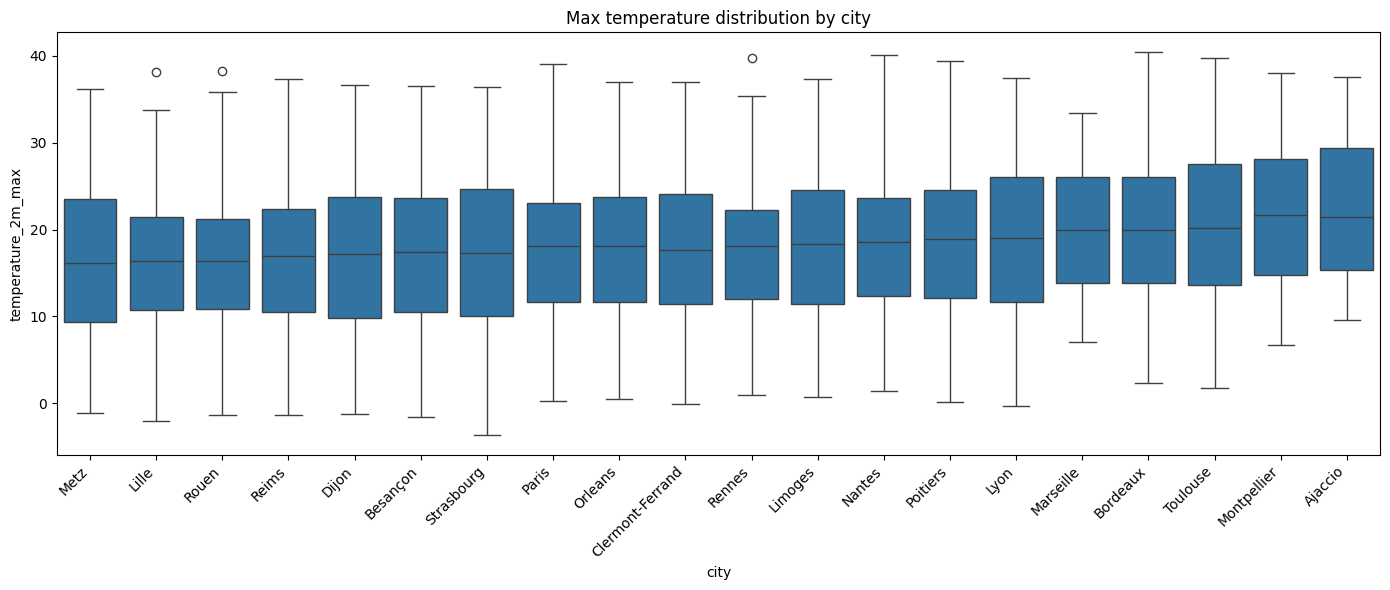

In [8]:
plt.figure(figsize=(14, 6))
order = city_stats.sort_values("temperature_2m_max")["city"]
sns.boxplot(data=weather_df, x="city", y="temperature_2m_max", order=order)
plt.xticks(rotation=45, ha="right")
plt.title("Max temperature distribution by city")
plt.tight_layout()
plt.savefig("../outputs/figures/boxplot_temp_max_city.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

### Interpretation

The distributions show noticeable differences in maximum temperatures across the selected cities. Southern cities generally exhibit higher temperature ranges and higher median values, while northern and eastern cities tend to experience cooler conditions.

The spread of the distributions also varies between cities, indicating that some locations experience greater seasonal temperature variability than others.

These comparisons illustrate the climatic diversity represented in the dataset and provide additional context for understanding local weather conditions.

## Monthly Summary by City

To compare seasonal patterns between locations, the weather observations are aggregated by city and month.

This monthly summary provides a structured view of local weather conditions throughout the year while reducing the variability observed in daily measurements.

It establishes a consistent basis for comparing seasonal behavior across the selected cities.

In [9]:
monthly_city = weather_df.groupby(["city", "month"])[
    ["temperature_2m_max", "temperature_2m_min", "precipitation_sum"]
].mean().reset_index()

monthly_city.head().round(2)

,city,month,temperature_2m_max,temperature_2m_min,precipitation_sum
0,Ajaccio,1,12.85,4.31,1.24
1,Ajaccio,2,14.79,4.55,1.27
2,Ajaccio,3,15.49,5.72,1.38
3,Ajaccio,4,17.86,7.12,3.16
4,Ajaccio,5,24.82,14.03,1.65


## Relationships Between Variables

After exploring each weather variable individually, the next step is to examine how they relate to one another.

Understanding these relationships helps identify whether changes in one variable tend to be associated with changes in another, providing additional insight into the overall structure of the dataset.

This analysis complements the previous observations by highlighting potential interactions between the main meteorological variables.

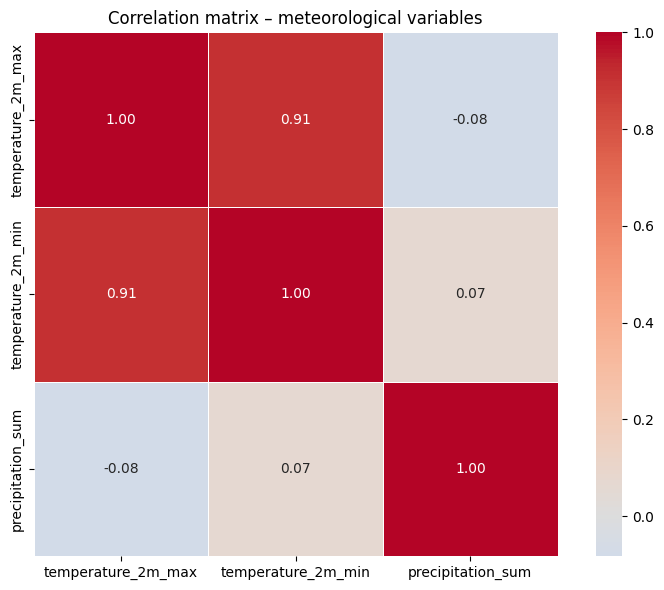

In [ ]:
corr_matrix = weather_df[[
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum"
]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation matrix – meteorological variables")
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

### Interpretation

Maximum and minimum temperatures show a strong positive correlation (**0.91**), indicating that warmer days are generally associated with warmer nights.

In contrast, precipitation exhibits little linear relationship with either temperature variable, with correlation values close to zero.

These results suggest that temperature variables evolve consistently together, while precipitation follows a more independent pattern within this dataset.

## Extreme Weather Events

Average weather conditions provide valuable context, but they do not fully capture the events that may have the greatest operational impact.

To complement the previous analyses, weather observations are grouped into categories representing hot days, freezing conditions, and heavy rainfall using predefined thresholds.

This approach provides a simple overview of how frequently different types of weather extremes occur across the selected cities.

In [ ]:
RAIN_THRESHOLD = 1.0
MODERATE_RAIN = 10.0
HEAVY_RAIN = 30.0
VERY_HEAVY_RAIN = 50.0

HOT_DAY = 25.0
VERY_HOT_DAY = 30.0
HEATWAVE_DAY = 35.0

TROPICAL_NIGHT = 20.0
FREEZING_DAY = 0.0
VERY_COLD_DAY = -5.0

# Rain categories
weather_df['rain_category'] = pd.cut(
    weather_df['precipitation_sum'],
    bins=[-0.1, 1, 10, 30, 50, weather_df['precipitation_sum'].max()],
    labels=[
        "Dry (<1 mm)",
        "Light rain (1-10 mm)",
        "Moderate rain (10-30 mm)",
        "Heavy rain (30-50 mm)",
        "Very heavy rain (>50 mm)"
    ]
)

# Hot categories
weather_df['hot_category'] = pd.cut(
    weather_df['temperature_2m_max'],
    bins=[-50, 25, 30, 35, 60],
    labels=[
        "Normal day (<25°C)",
        "Hot day (25-30°C)",
        "Very hot day (30-35°C)",
        "Heatwave day (>35°C)"
    ]
)

# Cold categories
weather_df['cold_category'] = pd.cut(
    weather_df['temperature_2m_min'],
    bins=[-50, -5, 0, 20, 60],
    labels=[
        "Very cold (<-5°C)",
        "Freezing (0°C)",
        "Normal night (0-20°C)",
        "Tropical night (>20°C)"
    ]
)

In [ ]:
extreme_stats = weather_df.groupby('city').agg({
    'hot_category': lambda x: (x == "Heatwave day (>35°C)").sum(),
    'cold_category': lambda x: (x == "Freezing (0°C)").sum(),
    'rain_category': lambda x: (x == "Heavy rain (30-50 mm)").sum() + (x == "Very heavy rain (>50 mm)").sum()
}).rename(columns={
    'hot_category': 'hot_days',
    'cold_category': 'cold_days',
    'rain_category': 'heavy_rain_days'
})

# Top 5 cities per events
print("Top 5 hot:")
print(extreme_stats.nlargest(5, 'hot_days'))
print("Top 5 cold:")
print(extreme_stats.nlargest(5, 'cold_days'))
print("Top 5 heavy_rain:")
print(extreme_stats.nlargest(5, 'heavy_rain_days'))

Top 5 hot:
             hot_days  cold_days  heavy_rain_days
city                                             
Toulouse           24         31                0
Montpellier        19         19                6
Bordeaux           13         24                2
Ajaccio             9          0                6
Lyon                7         49                1
Top 5 cold:
                  hot_days  cold_days  heavy_rain_days
city                                                  
Besançon                 2         54                1
Clermont-Ferrand         3         54                2
Dijon                    2         52                1
Lyon                     7         49                1
Strasbourg               3         49                0
Top 5 heavy_rain:
                  hot_days  cold_days  heavy_rain_days
city                                                  
Ajaccio                  9          0                6
Montpellier             19         19                6
Bord

### Interpretation

The summary highlights noticeable differences in the occurrence of extreme weather events across the selected cities.

Southern cities such as Toulouse and Montpellier record the highest number of heatwave days, while eastern cities including Besançon and Dijon experience more frequent freezing conditions. Heavy rainfall events are observed more often in cities such as Ajaccio and Montpellier.

These results illustrate the climatic diversity captured by the dataset and show that weather extremes are not evenly distributed across the study area.

## Statistical Anomaly Detection

While previous analyses focused on typical weather patterns, some observations may differ significantly from the usual conditions recorded in each city.

To identify these unusual events, standardized Z-scores are computed for temperature and precipitation. Observations exceeding a predefined threshold are flagged as statistical anomalies.

This provides a simple way to highlight potentially exceptional weather events without making assumptions about their underlying causes.

In [10]:
# Compute Z-scores for anomaly detection
weather_df['z_temp_max'] = weather_df.groupby('city')['temperature_2m_max'].transform(zscore)
weather_df['z_temp_min'] = weather_df.groupby('city')['temperature_2m_min'].transform(zscore)
weather_df['z_rain'] = weather_df.groupby('city')['precipitation_sum'].transform(zscore)


# Threshold for extreme events
ANOMALY_THRESHOLD = 2.0

# Flag anomalies
weather_df['temp_max_anomaly'] = weather_df['z_temp_max'].abs() > ANOMALY_THRESHOLD
weather_df['temp_min_anomaly'] = weather_df['z_temp_min'].abs() > ANOMALY_THRESHOLD
weather_df['rain_anomaly'] = weather_df['z_rain'].abs() > ANOMALY_THRESHOLD

In [11]:
anomalies_df = weather_df[
    weather_df['temp_max_anomaly'] |
    weather_df['temp_min_anomaly'] |
    weather_df['rain_anomaly']
]

anomalies_df.head(5).round(2)

,time,temperature_2m_max,temperature_2m_min,precipitation_sum,city,month,z_temp_max,z_temp_min,z_rain,temp_max_anomaly,temp_min_anomaly,rain_anomaly
3,2022-01-04,11.2,4.7,20.8,Paris,1,-0.79,-0.64,4.71,False,False,True
87,2022-03-29,18.0,9.4,10.2,Paris,3,0.09,0.15,2.06,False,False,True
97,2022-04-08,8.4,2.1,26.8,Paris,4,-1.15,-1.07,6.21,False,False,True
139,2022-05-20,22.0,13.0,16.4,Paris,5,0.60,0.75,3.61,False,False,True
158,2022-06-08,20.6,14.4,17.0,Paris,6,0.42,0.99,3.76,False,False,True


### Interpretation

The extracted observations illustrate how the anomaly detection process identifies weather measurements that deviate substantially from the typical conditions observed within each city.

In the displayed examples, the anomalies are primarily associated with unusually high precipitation values, while temperature measurements remain within their expected ranges.

These flagged observations provide a simple way to identify uncommon weather conditions for further analysis.

## Saving the Processed Dataset

The exploratory analysis has enriched the original dataset with additional variables and quality checks that will support the next stage of the project.

Saving this processed version ensures that all subsequent analyses rely on a consistent and reproducible dataset while preserving a clear separation between raw and prepared data.

In [ ]:
os.makedirs("../data/processed", exist_ok=True)

weather_df.to_csv(
    "../data/processed/weather_2022_processed.csv",
    index=False
)

print("Dataset saved to data/processed/weather_2022_processed.csv")

Dataset saved to data/processed/weather_2022_processed.csv


## Conclusion

The exploratory analysis provided a comprehensive overview of the dataset, revealing its main characteristics, seasonal patterns, regional differences, and relationships between key weather variables.

These observations help establish confidence in the data and provide a deeper understanding of the factors that may influence daily temperature variations.

With these insights in place, the dataset is now ready to be used for building a data-driven forecasting approach.